# 05 Churn Model

Build and compare customer churn prediction models using the synthetic customer dataset.

## Scope Note

This notebook builds predictive churn models only. Predictive feature importance is not the same as causal importance, and the results below should not be interpreted as causal estimates of price changes, discounts, or customer behavior.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
    plt.style.use("seaborn-v0_8-whitegrid")
except ModuleNotFoundError:
    plt = None
    HAS_MATPLOTLIB = False

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data" / "raw" / "customers.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

CUSTOMERS_PATH = PROJECT_ROOT / "data" / "raw" / "customers.csv"

RANDOM_STATE = 42
TEST_SIZE = 0.25

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.4f}".format)

## Load Customer Data

In [2]:
customers = pd.read_csv(
    CUSTOMERS_PATH,
    parse_dates=["first_purchase_date", "last_transaction_date"],
)

def normalize_boolean(series):
    """Normalize CSV boolean values while preserving invalid values as missing."""
    if pd.api.types.is_bool_dtype(series):
        return series
    return series.astype(str).str.lower().map({"true": True, "false": False})

for column in ["price_increase_occurred", "churned"]:
    customers[column] = normalize_boolean(customers[column])

customers["price_increase_exposure"] = customers["price_increase_occurred"].astype(int)
customers["discount_user"] = (customers["average_discount_percent"] > 0).astype(int)

display(customers.head())
display(customers["churned"].value_counts(normalize=True).rename("share").to_frame())

,customer_id,first_purchase_date,customer_region,acquisition_channel,customer_tenure_days,purchase_frequency,prior_spending,transaction_count,total_spending,average_discount_percent,price_increase_occurred,churned,last_transaction_date,price_increase_exposure,discount_user
0,C000001,2025-10-16,uk,direct,76,8.0000,103.9800,2,103.9800,0.0000,False,True,2025-11-08,0,0
1,C000002,2025-07-12,uk,influencer,172,4.2470,120.8300,2,120.8300,12.5000,False,False,2025-10-31,0,1
2,C000003,2025-07-12,north_america,influencer,172,6.3710,170.7700,3,170.7700,6.6700,False,False,2025-12-25,0,1
3,C000004,2024-08-08,rest_of_world,influencer,510,5.7290,491.9300,8,491.9300,8.7500,False,False,2025-12-13,0,1
4,C000005,2025-07-03,uk,affiliate,181,4.0360,104.9700,2,104.9700,0.0000,True,False,2025-07-29,1,0


,share
churned,
False,0.9272
True,0.0728


## Feature Set and Leakage Controls

The model uses customer behavior and segment features that would be appropriate for customer-level churn scoring. Direct identifiers, raw dates, and post-outcome style fields such as `last_transaction_date` are excluded to reduce leakage risk.

In [3]:
target = "churned"

numeric_features = [
    "price_increase_exposure",
    "purchase_frequency",
    "prior_spending",
    "customer_tenure_days",
    "average_discount_percent",
    "discount_user",
]
categorical_features = ["customer_region", "acquisition_channel"]
feature_columns = numeric_features + categorical_features

excluded_columns = sorted(set(customers.columns) - set(feature_columns) - {target})
display(pd.DataFrame({"model_features": feature_columns}))
display(pd.DataFrame({"excluded_columns": excluded_columns}))

,model_features
0,price_increase_exposure
1,purchase_frequency
2,prior_spending
3,customer_tenure_days
4,average_discount_percent
5,discount_user
6,customer_region
7,acquisition_channel


,excluded_columns
0,customer_id
1,first_purchase_date
2,last_transaction_date
3,price_increase_occurred
4,total_spending
5,transaction_count


## Train/Test Split

In [4]:
X = customers[feature_columns].copy()
y = customers[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(X_train), len(X_test)],
        "churn_rate": [y_train.mean(), y_test.mean()],
    }
)
display(split_summary)

,split,rows,churn_rate
0,train,9375,0.0729
1,test,3125,0.0726


## Preprocessing and Model Pipelines

In [5]:
def make_one_hot_encoder():
    """Create a one-hot encoder across supported scikit-learn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", make_one_hot_encoder(), categorical_features),
    ],
    remainder="drop",
)

forest_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_features),
        ("categorical", make_one_hot_encoder(), categorical_features),
    ],
    remainder="drop",
)

models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocess", logistic_preprocessor),
            (
                "model",
                LogisticRegression(
                    max_iter=1_000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocess", forest_preprocessor),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=500,
                    max_depth=5,
                    min_samples_leaf=25,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

## Fit Models and Evaluate Test Performance

In [6]:
def evaluate_model(model_name, model, X_test, y_test, threshold=0.5):
    """Evaluate a fitted classifier on the held-out test set."""
    predicted_probability = model.predict_proba(X_test)[:, 1]
    predicted_class = (predicted_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, predicted_class).ravel()
    return {
        "model": model_name,
        "roc_auc": roc_auc_score(y_test, predicted_probability),
        "precision": precision_score(y_test, predicted_class, zero_division=0),
        "recall": recall_score(y_test, predicted_class, zero_division=0),
        "f1_score": f1_score(y_test, predicted_class, zero_division=0),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "positive_prediction_rate": predicted_class.mean(),
    }


fitted_models = {}
evaluation_rows = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[model_name] = model
    evaluation_rows.append(evaluate_model(model_name, model, X_test, y_test))

model_comparison = pd.DataFrame(evaluation_rows).sort_values(
    ["roc_auc", "f1_score"],
    ascending=False,
)
display(model_comparison)

,model,roc_auc,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives,positive_prediction_rate
0,Logistic Regression,0.5335,0.0796,0.5022,0.1374,1580,1318,113,114,0.4582
1,Random Forest,0.5239,0.0837,0.5154,0.1440,1617,1281,110,117,0.4474


## Confusion Matrices

Logistic Regression


,Predicted: not churned,Predicted: churned
Actual: not churned,1580,1318
Actual: churned,113,114


Random Forest


,Predicted: not churned,Predicted: churned
Actual: not churned,1617,1281
Actual: churned,110,117


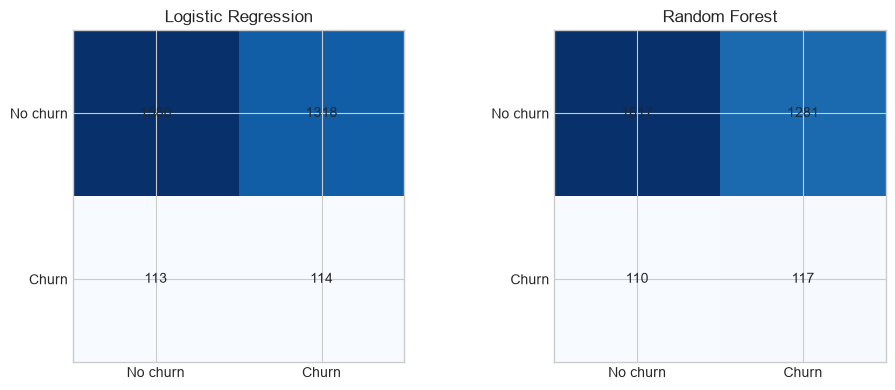

In [7]:
confusion_tables = []
for row in evaluation_rows:
    confusion_tables.append(
        pd.DataFrame(
            [
                [row["true_negatives"], row["false_positives"]],
                [row["false_negatives"], row["true_positives"]],
            ],
            index=["Actual: not churned", "Actual: churned"],
            columns=["Predicted: not churned", "Predicted: churned"],
        ).assign(model=row["model"])
    )

for table in confusion_tables:
    model_name = table.pop("model").iloc[0]
    print(model_name)
    display(table)

if HAS_MATPLOTLIB:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, row in zip(axes, evaluation_rows):
        matrix = [[row["true_negatives"], row["false_positives"]], [row["false_negatives"], row["true_positives"]]]
        ax.imshow(matrix, cmap="Blues")
        ax.set_title(row["model"])
        ax.set_xticks([0, 1], ["No churn", "Churn"])
        ax.set_yticks([0, 1], ["No churn", "Churn"])
        for i in range(2):
            for j in range(2):
                ax.text(j, i, matrix[i][j], ha="center", va="center")
    plt.tight_layout()
    plt.show()

## Feature Importance and Coefficients

These outputs describe predictive signal within each model. They should not be read as causal effects.

In [8]:
def get_transformed_feature_names(pipeline):
    """Return feature names produced by a fitted ColumnTransformer."""
    preprocessor = pipeline.named_steps["preprocess"]
    feature_names = []
    for transformer_name, transformer, columns in preprocessor.transformers_:
        if transformer_name == "remainder" and transformer == "drop":
            continue
        if transformer == "passthrough":
            feature_names.extend(columns)
        elif hasattr(transformer, "get_feature_names_out"):
            feature_names.extend(transformer.get_feature_names_out(columns))
        else:
            feature_names.extend(columns)
    return feature_names

,feature,coefficient,absolute_coefficient
0,price_increase_exposure,0.1819,0.1819
1,purchase_frequency,-0.1779,0.1779
8,customer_region_north_america,-0.1561,0.1561
4,average_discount_percent,-0.1519,0.1519
6,customer_region_asia_pacific,0.1450,0.1450
16,acquisition_channel_paid_social,0.1089,0.1089
13,acquisition_channel_email,-0.0933,0.0933
12,acquisition_channel_direct,-0.0771,0.0771
10,customer_region_uk,-0.0602,0.0602
9,customer_region_rest_of_world,0.0459,0.0459


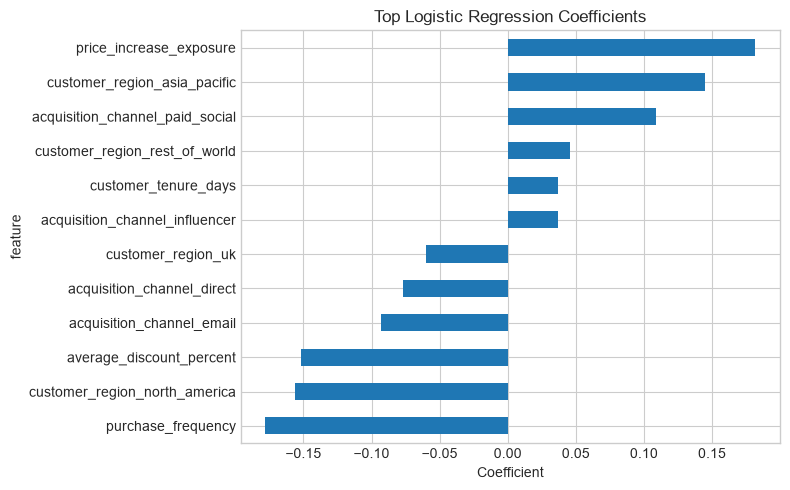

In [9]:
logistic_model = fitted_models["Logistic Regression"]
logistic_feature_names = get_transformed_feature_names(logistic_model)
logistic_coefficients = pd.DataFrame(
    {
        "feature": logistic_feature_names,
        "coefficient": logistic_model.named_steps["model"].coef_[0],
    }
)
logistic_coefficients["absolute_coefficient"] = logistic_coefficients["coefficient"].abs()
logistic_coefficients = logistic_coefficients.sort_values("absolute_coefficient", ascending=False)

display(logistic_coefficients.head(12))

if HAS_MATPLOTLIB:
    logistic_coefficients.head(12).sort_values("coefficient").plot(
        kind="barh",
        x="feature",
        y="coefficient",
        legend=False,
        figsize=(8, 5),
        title="Top Logistic Regression Coefficients",
    )
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

,feature,importance
1,purchase_frequency,0.2535
3,customer_tenure_days,0.2008
2,prior_spending,0.1603
4,average_discount_percent,0.1498
0,price_increase_exposure,0.0958
8,customer_region_north_america,0.0211
5,discount_user,0.0173
16,acquisition_channel_paid_social,0.0172
6,customer_region_asia_pacific,0.0162
13,acquisition_channel_email,0.0121


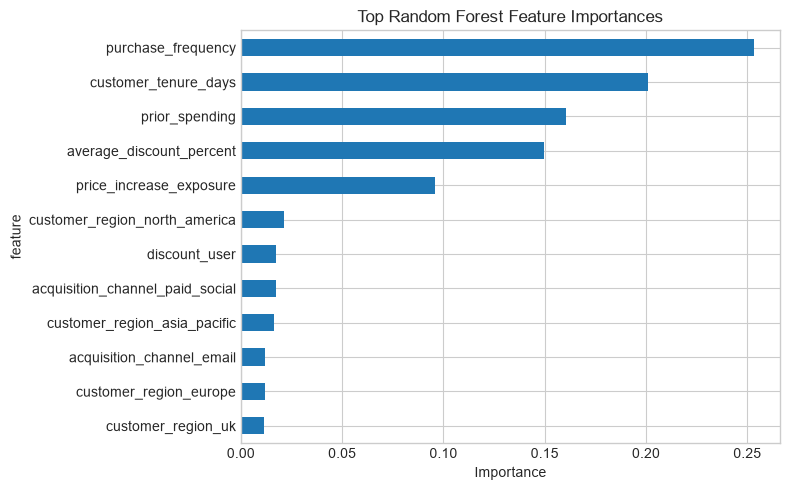

In [10]:
forest_model = fitted_models["Random Forest"]
forest_feature_names = get_transformed_feature_names(forest_model)
forest_importance = pd.DataFrame(
    {
        "feature": forest_feature_names,
        "importance": forest_model.named_steps["model"].feature_importances_,
    }
).sort_values("importance", ascending=False)

display(forest_importance.head(12))

if HAS_MATPLOTLIB:
    forest_importance.head(12).sort_values("importance").plot(
        kind="barh",
        x="feature",
        y="importance",
        legend=False,
        figsize=(8, 5),
        title="Top Random Forest Feature Importances",
    )
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

## Risk Score Sanity Check

,risk_decile,customers,average_predicted_churn,observed_churn_rate
0,1,313,0.3560,0.0735
1,2,312,0.4089,0.0417
2,3,313,0.4391,0.0511
3,4,312,0.4633,0.0641
4,5,313,0.4826,0.1022
5,6,312,0.5017,0.0801
6,7,312,0.5209,0.0833
7,8,313,0.5432,0.0671
8,9,312,0.5686,0.0865
9,10,313,0.6174,0.0767


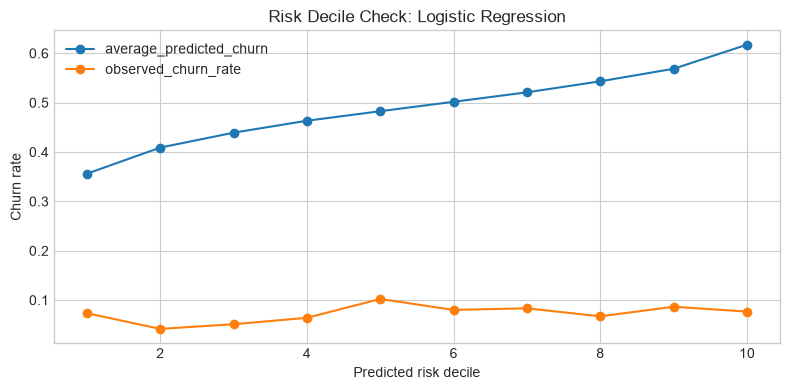

In [11]:
stronger_model_name = model_comparison.iloc[0]["model"]
stronger_model = fitted_models[stronger_model_name]
test_scores = stronger_model.predict_proba(X_test)[:, 1]
score_check = pd.DataFrame({"predicted_churn_probability": test_scores, "actual_churn": y_test.to_numpy()})
score_check["risk_decile"] = pd.qcut(
    score_check["predicted_churn_probability"],
    q=10,
    labels=False,
    duplicates="drop",
) + 1
risk_deciles = (
    score_check.groupby("risk_decile")
    .agg(
        customers=("actual_churn", "count"),
        average_predicted_churn=("predicted_churn_probability", "mean"),
        observed_churn_rate=("actual_churn", "mean"),
    )
    .reset_index()
)

display(risk_deciles)

if HAS_MATPLOTLIB:
    ax = risk_deciles.plot(
        x="risk_decile",
        y=["average_predicted_churn", "observed_churn_rate"],
        marker="o",
        figsize=(8, 4),
        title=f"Risk Decile Check: {stronger_model_name}",
    )
    ax.set_xlabel("Predicted risk decile")
    ax.set_ylabel("Churn rate")
    plt.tight_layout()
    plt.show()

## Model Findings

In [12]:
stronger_row = model_comparison.iloc[0]
baseline_row = model_comparison.loc[model_comparison["model"] == "Logistic Regression"].iloc[0]
forest_row = model_comparison.loc[model_comparison["model"] == "Random Forest"].iloc[0]
test_churn_rate = y_test.mean()

print("Model Findings")
print(f"- Models were retrained on {len(customers):,} regenerated customer records, with a held-out test churn rate of {test_churn_rate:.1%}.")
print(f"- Stronger test-set model by ROC-AUC: {stronger_row['model']}.")
print(
    f"- {stronger_row['model']} achieved ROC-AUC={stronger_row['roc_auc']:.3f}, "
    f"precision={stronger_row['precision']:.3f}, recall={stronger_row['recall']:.3f}, "
    f"and F1={stronger_row['f1_score']:.3f}."
)
print(
    f"- Logistic Regression: ROC-AUC={baseline_row['roc_auc']:.3f}, "
    f"precision={baseline_row['precision']:.3f}, recall={baseline_row['recall']:.3f}, "
    f"F1={baseline_row['f1_score']:.3f}."
)
print(
    f"- Random Forest: ROC-AUC={forest_row['roc_auc']:.3f}, "
    f"precision={forest_row['precision']:.3f}, recall={forest_row['recall']:.3f}, "
    f"F1={forest_row['f1_score']:.3f}."
)
if forest_row["f1_score"] > baseline_row["f1_score"]:
    print(
        "- Random Forest has the higher F1 score, but Logistic Regression remains "
        "the stronger model by ROC-AUC on this test split."
    )
print(
    "- The models show modest discrimination, which is expected because churn was "
    "generated probabilistically and remains noisy rather than deterministic."
)
print(
    "- Feature importance and coefficients are useful for model interpretation, "
    "but they are predictive signals only and should not be treated as causal effects."
)

Model Findings
- Models were retrained on 12,500 regenerated customer records, with a held-out test churn rate of 7.3%.
- Stronger test-set model by ROC-AUC: Logistic Regression.
- Logistic Regression achieved ROC-AUC=0.533, precision=0.080, recall=0.502, and F1=0.137.
- Logistic Regression: ROC-AUC=0.533, precision=0.080, recall=0.502, F1=0.137.
- Random Forest: ROC-AUC=0.524, precision=0.084, recall=0.515, F1=0.144.
- Random Forest has the higher F1 score, but Logistic Regression remains the stronger model by ROC-AUC on this test split.
- The models show modest discrimination, which is expected because churn was generated probabilistically and remains noisy rather than deterministic.
- Feature importance and coefficients are useful for model interpretation, but they are predictive signals only and should not be treated as causal effects.
